# Week 3 class: Influence Measures and Network Centralization

## Imports

In [ ]:
from rich.console import Console
from rich.columns import Columns
import networkx as nx
import social_networks.visualize as viz
import social_networks.utils as ut
from networkx.generators.directed import gn_graph


%matplotlib widget

%load_ext autoreload
%autoreload 2

# Degree and Closeness Centrality

## Degree Centrality - Directed networks

### Definition

$$
C_\text{indeg}(\nu) = \frac{d_\nu^{\text{in}}}{|N| - 1}
$$
$N =$ set of nodes in the network  
$d_\nu ^\text{in} = $ the in-degree of node $\nu$


### Example

    indeg_cent = nx.in_degree_centrality(g)

In [4]:
G = nx.karate_club_graph()
# This line shifts the labels by 1 (instead of starting at 0)
G = nx.convert_node_labels_to_integers(G, first_label=1)

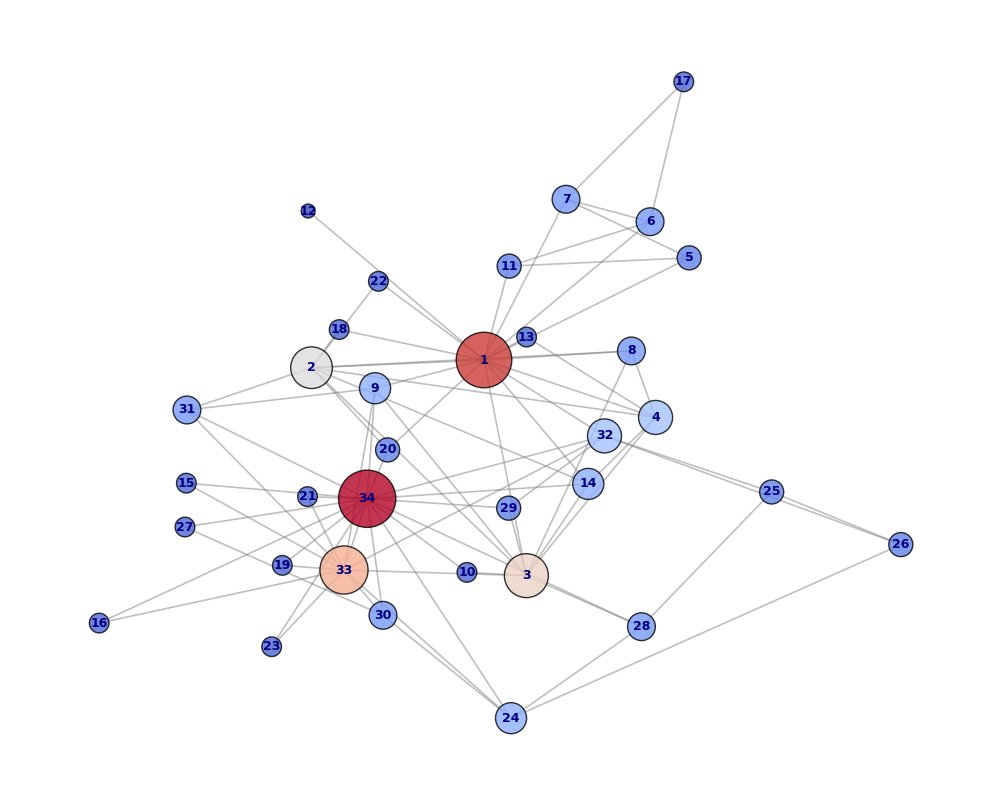

In [5]:
viz.draw_pretty_hover(G, scale_by_degree=True, color_by_degree=True);

In [6]:
deg_cent = nx.degree_centrality(G)

In [7]:
deg_cent[34]
# = 17/33

0.5151515151515151

In [8]:
deg_cent[33]
# = 12/33

0.36363636363636365

## Closeness Centrality

Normalized 
* Scaled to [0, 1]
* Normally used

\begin{aligned}
C_\text{close-norm}(\nu) &= \frac{|N| - 1} {\sum_{u \in N \setminus \nu} d(\nu, u)} \\
&= \frac{\text{Num. of nodes} - 1} {\text{Sum of the distance to all nodes from } \nu}
\end{aligned}

The max value $= 1$ occurs when the node $\nu$ is connected to every node, so 
$$d(\nu, u) = 1; \forall u$$

Unnormalized

$$
C_\text{close-unnorm}(\nu) = \frac{1} {\sum_{u \in N \setminus \nu} d(\nu, u)}
$$



In [9]:
close_cent = nx.closeness_centrality(G)
close_cent[32]

0.5409836065573771

In [10]:
sum_distances = sum(nx.shortest_path_length(G, 32).values())
num_nodes_minus_1 = len(G.nodes) - 1
print(f"{sum_distances=}")
print(f"{num_nodes_minus_1=}")

sum_distances=61
num_nodes_minus_1=33


In [11]:
num_nodes_minus_1 / sum_distances

0.5409836065573771

## Disconnected Nodes

What do we do when a node cannot reach all other nodes?

### Option 1 (too high?)

\begin{aligned}
C_\text{close}(\nu) &= \frac{|R(\nu)|} {\sum_{u \in R(\nu)} d(\nu, u)} \\
&= \frac{\text{Num. of nodes } \nu \text{ can reach}} {\text{Sum of the dist to all nodes from } \nu \text{that it can reach}}
\end{aligned}

### Option 2 - Normalize

Normalize by fraction of nodes $\nu$ can reach

\begin{aligned}
C_\text{close}(\nu) &= \frac{|R(\nu)|} {|N - 1|} \frac{|R(\nu)|} {\sum_{u \in R(\nu)} d(\nu, u)} \\
&= \Bigl(\frac{\text{Num nodes can reach}}{\text{Num nodes except itself}}\Bigr)
\Bigl(\frac{\text{Num. of nodes } \nu \text{ can reach}} {\text{Sum of the dist to all nodes from } \nu \text{that it can reach}}\Bigr)
\end{aligned}



For an undirected graph, the normalized (wf_improved=True) and unnormalized values are the samem

In [12]:
close_cent_1 = nx.closeness_centrality(G, wf_improved=False)
close_cent_2 = nx.closeness_centrality(G, wf_improved=True)

In [13]:
print(f"{close_cent_1[34]=}")
print(f"{close_cent_2[34]=}")

close_cent_1[34]=0.55
close_cent_2[34]=0.55


# Betweenness Centrality

### Definition (for nodes)

What are the nodes that show up in the shortest paths between nodes?

$$
C_\text{btw}(\nu) = \sum_{s, t \in N}  \frac{\sigma_{s,t}(\nu)} {\sigma_{s,t}}
$$
$\sigma_{s,t} = $ Number of shortest paths between nodes $s$ and $t$   
$\sigma_{s,t}(\nu) = $ Number of shortest paths between nodes $s$ and $t$ that pass through $\nu$

When choosing nodes $s$ and $t$, we can either include or exclude the node $\nu$.  
Including $\nu$ results in a highter betweenness centrality.

`networkx` allows you to include or exclude the endpoint.

### Question

A-B, A-C = 0  
A-E A-F A-G = 1 + 1 + 1 = 3  
B-C = 0  
B-E, B-F B-G = 1 + 1 + 1 = 3  
C-E, C-F, C-G = 3  
E-F, E-G = 0  
F-G = 0  


= 9

## Disconnected Nodes

Some pairs of nodes cannot reach each other (often happens in directed graphs)

In this case, only consider nodes $s, t$ such that there is at least 1 path between them.

## Normalization

Larger graphs will natrually have a larger betweenness centrality.

Normalize by dividing by the number of pairs of nodes in the graph (excluding $\nu$)  
$N$ = number of nodes including $\nu$

\begin{aligned}
\text{undirected graphs} &: \frac{1}{2}\Bigl(|N| - 1\Bigr)\Bigl(|N| - 2\Bigr) \\
\text{directed graphs} &: \Bigl(|N| - 1\Bigr)\Bigl(|N| - 2\Bigr)
\end{aligned}

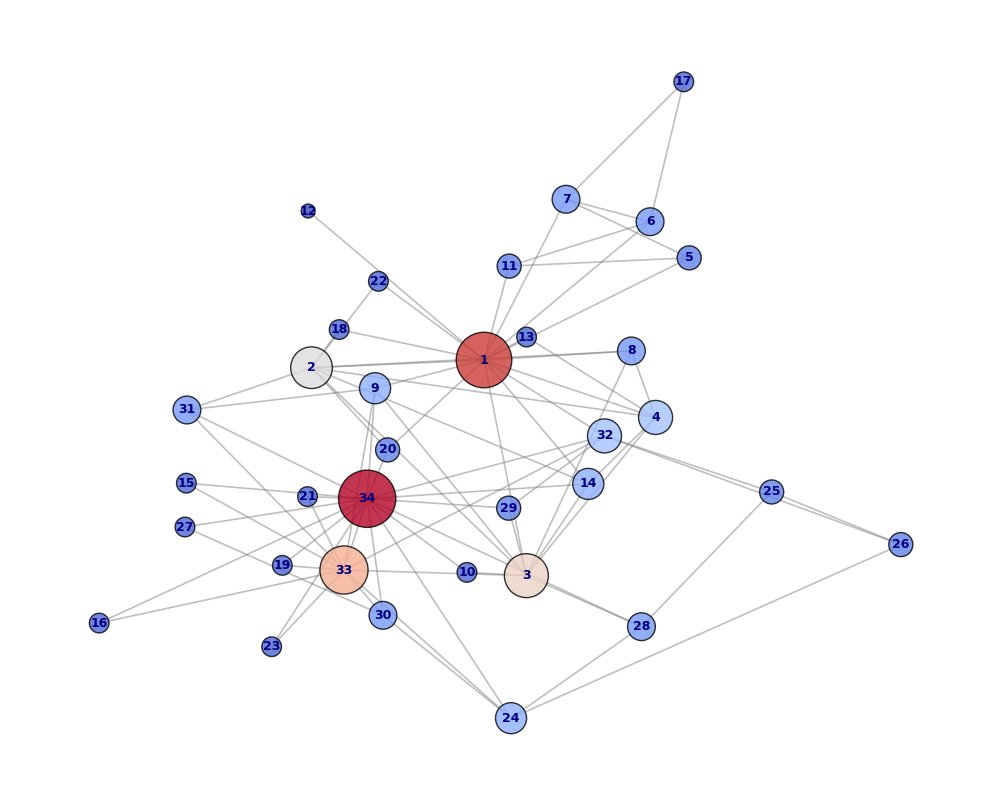

In [14]:
g = nx.karate_club_graph()
g = nx.convert_node_labels_to_integers(g, first_label=1)
viz.draw_pretty_hover(g, scale_by_degree=True, color_by_degree=True)
btw_cent = nx.betweenness_centrality(g, normalized=True, endpoints=False)

In [15]:
btw_cent

{1: 0.43763528138528146,
 2: 0.053936688311688304,
 3: 0.14365680615680618,
 4: 0.011909271284271283,
 5: 0.0006313131313131313,
 6: 0.02998737373737374,
 7: 0.029987373737373736,
 8: 0.0,
 9: 0.05592682780182781,
 10: 0.0008477633477633478,
 11: 0.0006313131313131313,
 12: 0.0,
 13: 0.0,
 14: 0.04586339586339586,
 15: 0.0,
 16: 0.0,
 17: 0.0,
 18: 0.0,
 19: 0.0,
 20: 0.03247504810004811,
 21: 0.0,
 22: 0.0,
 23: 0.0,
 24: 0.017613636363636363,
 25: 0.0022095959595959595,
 26: 0.0038404882154882154,
 27: 0.0,
 28: 0.02233345358345358,
 29: 0.0017947330447330447,
 30: 0.0029220779220779218,
 31: 0.014411976911976909,
 32: 0.13827561327561325,
 33: 0.145247113997114,
 34: 0.30407497594997596}

## Time to compute

This can take a long time to calculate.  
$\text{time} \sim O(|N|^3)$

Approximate by taking a sample

In [16]:
btw_cent_approx = nx.betweenness_centrality(g, normalized=True, endpoints=False, k=10)
btw_cent_approx

{1: 0.4656882816257817,
 2: 0.056099386724386725,
 3: 0.16111516955266952,
 4: 0.022931397306397306,
 5: 0.0,
 6: 0.016098484848484848,
 7: 0.016098484848484848,
 8: 0.0,
 9: 0.04797348484848484,
 10: 0.0,
 11: 0.0,
 12: 0.0,
 13: 0.0,
 14: 0.030392917267917267,
 15: 0.0,
 16: 0.0,
 17: 0.0,
 18: 0.0,
 19: 0.0,
 20: 0.023381132756132753,
 21: 0.0,
 22: 0.0,
 23: 0.0,
 24: 0.009551767676767676,
 25: 0.0,
 26: 0.008979377104377104,
 27: 0.0,
 28: 0.04396675084175085,
 29: 0.0,
 30: 0.0032196969696969696,
 31: 0.013476731601731603,
 32: 0.1605197811447811,
 33: 0.11885792448292448,
 34: 0.30846741221741225}

In [17]:
sorted(btw_cent_approx.items(), key=lambda x: float(x[1]), reverse=True)[:5]

[(1, 0.4656882816257817),
 (34, 0.30846741221741225),
 (3, 0.16111516955266952),
 (32, 0.1605197811447811),
 (33, 0.11885792448292448)]

In [18]:
sorted(btw_cent.items(), key=lambda x: float(x[1]), reverse=True)[:5]

[(1, 0.43763528138528146),
 (34, 0.30407497594997596),
 (33, 0.145247113997114),
 (3, 0.14365680615680618),
 (32, 0.13827561327561325)]

## Subsets

Compute based on 2 subgroups.

What are the most important nodes in this network that show up in the shortest paths between 2 subgroups (source and target groups).

In [20]:
bc_subset = nx.betweenness_centrality_subset(
    G=g,
    sources=[34, 33, 21, 30, 16, 27, 15, 23, 10],
    targets=[1, 4, 13, 11, 6, 12, 17, 7],
    normalized=True,
)

In [21]:
ut.top_n_by_dict_val(bc_subset, 5)

[(1, 0.04899515993265994),
 (34, 0.028807419432419434),
 (3, 0.018368205868205867),
 (33, 0.01664712602212602),
 (9, 0.014519450456950456)]

### Definition (for edges)

$$
C_\text{btw}(e) = \sum_{s, t \in N}  \frac{\sigma_{s,t}(e)} {\sigma_{s,t}}
$$
$\sigma_{s,t} = $ Number of shortest paths between nodes $s$ and $t$   
$\sigma_{s,t}(e) = $ Number of shortest paths between nodes $s$ and $t$ that pass through edge $e$

#### Example

In [22]:
bc_edge = nx.edge_betweenness_centrality(g, normalized=True)

In [23]:
ut.top_n_by_dict_val(bc_edge, 5)

[((1, 32), 0.1272599949070537),
 ((1, 7), 0.07813428401663695),
 ((1, 6), 0.07813428401663694),
 ((1, 3), 0.0777876807288572),
 ((1, 9), 0.07423959482783014)]

# Basic Page Rank

## Definitions

$n =$ number of nodes in the network  
$k =$ number of steps  

1. Assign all nodes a PageRank $= \frac{1}{n}$
2. Perform Basic PageRank Update rule $k$ times

*Basic PageRank Update Rule*:  
Each node gives an equal share of its current
PageRank to all the nodes it links to

The new PageRank of each node is the sum of all the PageRank it received from
other nodes

# Scaled Page Rank

## Interpreting PageRank

The PageRank of a node at step $k$ is the probability that at **random walker** lands on a node after taking $k$ steps.

## Random walk with damping parameter $\alpha$

1. Start on a random node  
* With probability $\alpha$ choose an outgoing edge and follow it to the next node.
* With probability $1 - \alpha$ choose a node at random and go to it.  
2. Repeat $k$ times

The random walk will no longer get "stuck" in any cycles.

In practice, $\alpha$ is between $0.8-0.9$

The Scaled PageRank of node $n$ at step $k$ with damping factor $\alpha$ is the probability that at **random walker with damping** lands on node $n$ after taking $k$ steps.

In [24]:
pr = nx.pagerank(G=g, alpha=0.8)

In [25]:
ut.top_n_by_dict_val(pr, 5)

[(34, 0.09486047671556612),
 (1, 0.08681447719172829),
 (33, 0.07407774615757656),
 (3, 0.06022609788477227),
 (2, 0.05576990180502326)]

# Hubs and Authorities

* Authority: Most relevant
    * Valuable resources (authorities)
* Hub: Points to the most relevant nodes
    * Good at linking to valuable resources (hubs)

## HITS Algorithm

Hyperlink-Induced Topic Search

Used to analyze the link structure of networks, particularly web pages.

1. Authority Score:

    * This score measures the value of a node based on the number of incoming links from other nodes that are considered hubs.
    * A high authority score indicates that a node is linked to by many high-quality hubs, suggesting it is a valuable source of information.

2. Hub Score:
    * This score measures the value of a node based on the number of outgoing links to other nodes that are considered authorities.
    * A high hub score indicates that a node links to many high-quality authority nodes, suggesting it is a good resource for finding valuable information.


1. Root: Potential *Authorities*. E.g. pages that contain the query string
2. Base: Root nodes + any node that links to a node in Root
3. Consider all edges connecting nodes in the base set.

Computing $k$ iterations of the HITS algo to assign an *authority score* and *hub score* to each node

1. Assign each node an authority and hub score of $1$.
2. Apply the **Authority Update Rule**: each node’s *authority* score is the sum of *hub* scores of each node that *points to it*.
3. Apply the **Hub Update Rule**: each node’s *hub* score is the sum of *authority* scores of each node that *it points to*.
4. **Nomalize Authority and Hub scores**: 
\begin{aligned}
\text{auth}(j) &= \frac{\text{auth}(j)}{\sum_{i \in N} \text{auth}(i)} \\
\text{hub}(j) &= \frac{\text{hub}(j)}{\sum_{i \in N} \text{hub}(i)}
\end{aligned}
5. Repeat $k$ times.

For most networks, as $k \rightarrow \infin$ gets larger

### Example

In [27]:
# Put this in a function in utils.py
# ut.print_top_hubs_auths(g, k=5)

hits_hubs, hits_auths = nx.hits(g)

k = 5
top_hubs = ut.top_n_by_dict_val(hits_hubs, k)
top_auths = ut.top_n_by_dict_val(hits_auths, k)

hub_table = ut.build_table("Top Hubs", top_hubs)
auth_table = ut.build_table("Top Auths", top_auths)

# Display side by
console = Console()
console.print(Columns([hub_table, auth_table]))

    Top Hubs        Top Auths    
┏━━━━━━┳━━━━━━━┓ ┏━━━━━━┳━━━━━━━┓
┃ Node ┃ Score ┃ ┃ Node ┃ Score ┃
┡━━━━━━╇━━━━━━━┩ ┡━━━━━━╇━━━━━━━┩
│ 34   │ 0.078 │ │ 34   │ 0.078 │
│ 3    │ 0.077 │ │ 3    │ 0.077 │
│ 33   │ 0.071 │ │ 33   │ 0.071 │
│ 1    │ 0.067 │ │ 1    │ 0.067 │
│ 2    │ 0.065 │ │ 2    │ 0.065 │
└──────┴───────┘ └──────┴───────┘

In [28]:
ut.print_top_hubs_auths(g, 5);

    Top Hubs        Top Auths    
┏━━━━━━┳━━━━━━━┓ ┏━━━━━━┳━━━━━━━┓
┃ Node ┃ Score ┃ ┃ Node ┃ Score ┃
┡━━━━━━╇━━━━━━━┩ ┡━━━━━━╇━━━━━━━┩
│ 34   │ 0.078 │ │ 34   │ 0.078 │
│ 3    │ 0.077 │ │ 3    │ 0.077 │
│ 33   │ 0.071 │ │ 33   │ 0.071 │
│ 1    │ 0.067 │ │ 1    │ 0.067 │
│ 2    │ 0.065 │ │ 2    │ 0.065 │
└──────┴───────┘ └──────┴───────┘

### Synthetic example

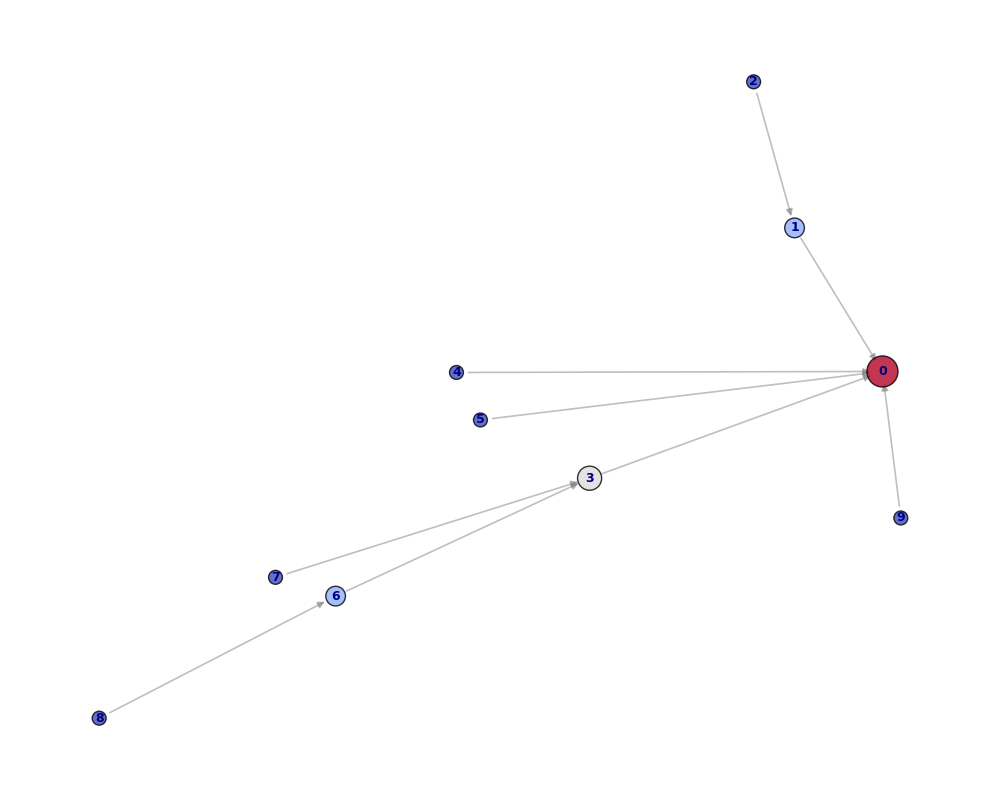

In [ ]:

g_dgnp = gn_graph(n=10, seed=42)
viz.draw_pretty_hover(g_dgnp, scale_by_degree=True, color_by_degree=True);

In [30]:
ut.print_top_hubs_auths(g_dgnp, 10);

    Top Hubs          Top Auths    
┏━━━━━━┳━━━━━━━━┓ ┏━━━━━━┳━━━━━━━━┓
┃ Node ┃  Score ┃ ┃ Node ┃  Score ┃
┡━━━━━━╇━━━━━━━━┩ ┡━━━━━━╇━━━━━━━━┩
│ 1    │  0.200 │ │ 0    │  1.000 │
│ 3    │  0.200 │ │ 3    │  0.000 │
│ 4    │  0.200 │ │ 1    │  0.000 │
│ 5    │  0.200 │ │ 2    │ -0.000 │
│ 9    │  0.200 │ │ 4    │ -0.000 │
│ 6    │  0.000 │ │ 5    │ -0.000 │
│ 7    │  0.000 │ │ 6    │ -0.000 │
│ 2    │  0.000 │ │ 7    │ -0.000 │
│ 0    │ -0.000 │ │ 8    │ -0.000 │
│ 8    │ -0.000 │ │ 9    │ -0.000 │
└──────┴────────┘ └──────┴────────┘

# Centrality Examples

## Comparing Centrality Measures

* In-degree : how many nodes point to you  
Popularity by count
* Closeness : Nodes that are central are a short distance away from all other nodes
* Betweenness : Central nodes show up in the shortest paths between nodes
* Page Rank : If you took a random walk, you would land on them a lot  
Weights the number and *quality* of incoming links  
Influence by *who* follows you
* Authority Score : Nodes that are good resources
* Hub Score : Nodes that will link you to good resources